# CIFAR-10 Baseline Experiment

This notebook begins the experimental phase of the ViT project. The model and reusable loops are imported from the package rather than redefined in notebook cells.

**Protocol**

1. Split the official CIFAR-10 training data into 45,000 training examples and 5,000 validation examples.
2. Train a fresh ViT from scratch.
3. Use validation loss for early stopping and model selection.
4. Evaluate the official test set once after restoring the best checkpoint.


In [ ]:
%load_ext autoreload
%autoreload 2

import copy
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import torch
from torchvision import transforms
from tqdm.auto import tqdm

from vit_reimplementation import (
    ViT,
    create_cifar10_splits,
    create_data_loaders,
    evaluate_model,
    train_one_epoch,
)

## Configuration

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data"
CHECKPOINT_PATH = (
    PROJECT_ROOT
    / "checkpoints"
    / "cifar10_baseline.pt"
)

SEED = 0

IMAGE_SIZE = (32, 32)
PATCH_SIZE = (4, 4)
CHANNELS = 3
DIM = 96
NUM_LAYERS = 3
NUM_HEADS = 4
HIDDEN_DIM = 384
NUM_CLASSES = 10

TRAIN_BATCH_SIZE = 128
EVAL_BATCH_SIZE = 256
NUM_EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.01
PATIENCE = 8
MIN_DELTA = 1e-3

# Reproducible initialization and train/validation split.
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using:", device)


Using: mps


## Data

The baseline begins without augmentation so its behavior is easy to attribute. Later experiments can add random crops and horizontal flips only to `train_transform`.


In [4]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset, validation_dataset, test_dataset = create_cifar10_splits(
    root=DATA_ROOT,
    validation_size=5_000,
    seed=SEED,
    train_transform=train_transform,
    eval_transform=eval_transform,
)

train_loader, validation_loader, test_loader = create_data_loaders(
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    test_dataset=test_dataset,
    train_batch_size=TRAIN_BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    num_workers=0,
)

print("Train examples:", len(train_dataset))
print("Validation examples:", len(validation_dataset))
print("Test examples:", len(test_dataset))
print()
print("Train batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))


Train examples: 45000
Validation examples: 5000
Test examples: 10000

Train batches: 352
Validation batches: 20
Test batches: 40


## Fresh model

In [5]:
# Re-run this cell before each independent experiment so the model starts fresh.
torch.manual_seed(SEED)

model = ViT(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    channels=CHANNELS,
    dim=DIM,
    num_layers=NUM_LAYERS,
    num_heads=NUM_HEADS,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

num_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Parameters: {num_parameters:,}")


Parameters: 346,570


## Train with validation-based early stopping

Each retained progress bar has two stages: one full training pass and one full validation pass. The best model is selected by minimum validation loss.


In [6]:
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
best_state = None

for epoch in range(NUM_EPOCHS):
    progress_bar = tqdm(
        total=2,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}",
        unit="stage",
        leave=True,
    )

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        device=device,
    )
    progress_bar.update(1)

    val_loss, val_accuracy = evaluate_model(
        model=model,
        loader=validation_loader,
        device=device,
    )
    progress_bar.update(1)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    progress_bar.set_postfix(
        train_loss=f"{train_loss:.4f}",
        train_acc=f"{train_accuracy:.2%}",
        val_loss=f"{val_loss:.4f}",
        val_acc=f"{val_accuracy:.2%}",
    )
    progress_bar.close()

    improved = val_loss < best_val_loss - MIN_DELTA

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(
            f"Early stopping at epoch {epoch + 1}. "
            f"Best epoch was {best_epoch} "
            f"with val_loss={best_val_loss:.4f}."
        )
        break

if best_state is None:
    raise RuntimeError("Training completed without recording a model state")

model.load_state_dict(best_state)

CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
torch.save(
    {
        "model_state_dict": best_state,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "history": history,
    },
    CHECKPOINT_PATH,
)

print("Restored best model from epoch", best_epoch)
print("Saved checkpoint to", CHECKPOINT_PATH)


Epoch 1/100: 100%|█| 2/2 [00:10<00:00,  5.02s/stage, train_acc=25.26%, train_loss=2.0130, val_acc=34.04%,
Epoch 2/100: 100%|█| 2/2 [00:09<00:00,  4.90s/stage, train_acc=37.83%, train_loss=1.7327, val_acc=40.88%,
Epoch 3/100: 100%|█| 2/2 [00:09<00:00,  4.84s/stage, train_acc=42.69%, train_loss=1.6075, val_acc=44.64%,
Epoch 4/100: 100%|█| 2/2 [00:09<00:00,  4.72s/stage, train_acc=45.77%, train_loss=1.5157, val_acc=46.58%,
Epoch 5/100: 100%|█| 2/2 [00:09<00:00,  4.99s/stage, train_acc=48.34%, train_loss=1.4465, val_acc=46.94%,
Epoch 6/100: 100%|█| 2/2 [00:09<00:00,  4.96s/stage, train_acc=50.27%, train_loss=1.3903, val_acc=49.42%,
Epoch 7/100: 100%|█| 2/2 [00:10<00:00,  5.05s/stage, train_acc=51.48%, train_loss=1.3475, val_acc=51.08%,
Epoch 8/100: 100%|█| 2/2 [00:10<00:00,  5.15s/stage, train_acc=53.45%, train_loss=1.3017, val_acc=50.78%,
Epoch 9/100: 100%|█| 2/2 [00:10<00:00,  5.37s/stage, train_acc=54.77%, train_loss=1.2592, val_acc=52.10%,
Epoch 10/100: 100%|█| 2/2 [00:10<00:00,  5.37s

Early stopping at epoch 21. Best epoch was 13 with val_loss=1.2780.
Restored best model from epoch 13
Saved checkpoint to /Users/cedric/Repos/vit-reimplementation/checkpoints/cifar10_baseline.pt


## Visualize learning curves

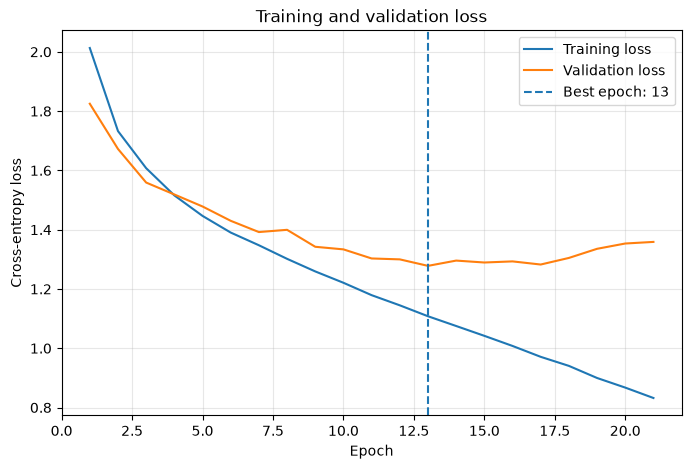

In [7]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Training loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")
plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


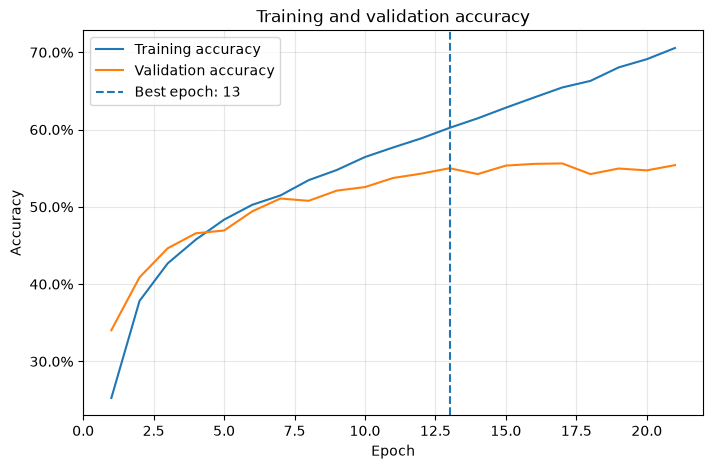

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_accuracy"], label="Training accuracy")
plt.plot(epochs, history["val_accuracy"], label="Validation accuracy")
plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch: {best_epoch}",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and validation accuracy")
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Final test evaluation

Run this only after the model and hyperparameters are fixed. The official CIFAR-10 test split should not guide model development.


In [ ]:
test_loss, test_accuracy = evaluate_model(
    model=model,
    loader=test_loader,
    device=device,
)

print(
    f"Final test loss: {test_loss:.4f} | "
    f"Final test accuracy: {test_accuracy:.2%}"
)


## Next controlled experiment

After recording this baseline, change one factor at a time. A natural next experiment is training-only augmentation:

```python
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
```

Keep validation and test transforms deterministic so comparisons remain meaningful.
